# NYC Taxi Demand Forecasting

## Notebook 03: Data Cleaning

---

## Objective

The goal of this notebook is to improve data quality before creating the forecasting dataset.

Data collected from real-world systems often contains invalid records, missing values, duplicate entries, and outliers.

These issues can affect the quality of analysis and reduce model performance.

---

## Why Data Cleaning?

Before building forecasting models, we must ensure that the dataset is reliable and consistent.

Cleaning helps us:

- Remove invalid records
- Validate important fields
- Investigate outliers
- Improve overall data quality

---

## Expected Outcome

By the end of this notebook:

- Data quality issues will be identified.
- Invalid records will be handled.
- Cleaning decisions will be documented.
- A cleaned dataset will be saved for further processing.

# Step 1: Import Libraries and Load Dataset

Import required libraries and load the dataset for cleaning.

This notebook works on the original Yellow Taxi dataset.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)

df = pd.read_parquet(
    "/home/ed/Desktop/NYC_Taxi_Demand_Forecasting/Yellow_Dataset/data/yellow_tripdata_2026-01.parquet"
)

print("Dataset loaded successfully.")
print(f"Dataset Shape: {df.shape}")
print("Top 5 rows of the dataset:")
print(df.head())

Dataset loaded successfully.
Dataset Shape: (3724889, 20)
Top 5 rows of the dataset:
   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0         2  2026-01-01 00:54:04   2026-01-01 00:59:37              1.0   
1         1  2026-01-01 00:34:04   2026-01-01 00:39:47              0.0   
2         1  2026-01-01 00:57:06   2026-01-01 01:05:59              0.0   
3         2  2026-01-01 00:15:22   2026-01-01 00:58:10              4.0   
4         2  2026-01-01 00:27:13   2026-01-01 00:40:43              0.0   

   trip_distance  RatecodeID store_and_fwd_flag  PULocationID  DOLocationID  \
0           0.97         1.0                  N           239           238   
1           0.90         1.0                  N           163           162   
2           1.40         1.0                  N            43           237   
3           5.58         1.0                  N           142           209   
4           2.16         1.0                  N            88        

# Step 2: Missing Value Review

## Purpose

Identify columns containing missing values and evaluate whether they impact the forecasting use case.

## Description

Missing values do not always require treatment. Their impact depends on whether they affect the target variable or important features used for forecasting.

## Expected Outcome

- Identify columns with missing values.
- Determine whether missing values affect demand forecasting.
- Decide whether treatment is necessary.

In [2]:
missing = (
    df.isnull().sum().sort_values(ascending=False)
)

missing[missing > 0]

passenger_count         1088058
congestion_surcharge    1088058
store_and_fwd_flag      1088058
RatecodeID              1088058
Airport_fee             1088058
dtype: int64

## Observation

Multiple columns contain missing values, but they are not directly related to the forecasting target.

## Conclusion

Since the required forecasting columns are unaffected, the missing values are retained and no treatment is applied.

# Step 3:Datetime Validation

## Purpose

Verify that pickup and dropoff timestamps are valid and logically consistent.

## Description

A taxi trip cannot end before it starts. Invalid timestamps can affect time-based analysis and demand creation.

## Expected Outcome

- Identify invalid trip records.
- Validate the reliability of datetime columns.
- Ensure the dataset is suitable for time-series forecasting.

In [ ]:
invalid_trips = (
    df['tpep_dropoff_datetime']
    <
    df['tpep_pickup_datetime']
).sum()

print
(f"Invalid Trips: {invalid_trips:,}")

Invalid Trips: 1


In [14]:
df = df[
    df['tpep_dropoff_datetime']
    >=
    df['tpep_pickup_datetime']
]

## Conclusion

One invalid trip record was identified where the dropoff time occurred before the pickup time.

Since such records are logically impossible, they were removed from the dataset.

# Step 4:Duplicate Record Analysis

## Purpose

Check for duplicate trip records in the dataset.

## Description

Duplicate records can artificially increase demand counts and lead to inaccurate forecasting.

## Expected Outcome

- Identify duplicate records.
- Determine whether duplicate removal is required.

In [4]:
duplicates = df.duplicated().sum()

print(f"Duplicate Records: {duplicates:,}")

Duplicate Records: 0


# Step 5:Passenger Count Validation

## Purpose

Review passenger count values for potential data quality issues.

## Description

Passenger counts should contain realistic values. Unusual values may indicate recording errors.

## Expected Outcome

- Understand passenger count distribution.
- Detect unrealistic values.
- Assess data quality.

In [5]:
df['passenger_count'].describe()

count    2.636831e+06
mean     1.256271e+00
std      6.702431e-01
min      0.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      1.000000e+00
max      9.000000e+00
Name: passenger_count, dtype: float64

In [6]:
df['passenger_count'].value_counts().sort_index()

passenger_count
0.0      14787
1.0    2150994
2.0     334370
3.0      72864
4.0      49738
5.0       9184
6.0       4887
7.0          2
8.0          4
9.0          1
Name: count, dtype: int64

# Step 6:Trip Distance Validation

## Purpose

Evaluate trip distance values and identify unrealistic records.

## Description

Trip distance is expected to contain positive values within a realistic range for NYC taxi trips.

## Expected Outcome

- Detect negative or zero distances.
- Identify unusually large trip distances.
- Assess the presence of outliers.

In [7]:
df['trip_distance'].describe()

count    3.724889e+06
mean     6.455647e+00
std      6.488855e+02
min      0.000000e+00
25%      1.000000e+00
50%      1.810000e+00
75%      3.730000e+00
max      2.690975e+05
Name: trip_distance, dtype: float64

In [8]:
df['trip_distance'].nlargest(10)

3524923    269097.48
3632367    237567.19
3285750    236216.69
3131676    236183.06
2704619    221544.91
2688274    221436.73
3131406    196490.48
3571687    192081.68
2820951    184908.33
3499856    183363.75
Name: trip_distance, dtype: float64

In [9]:
df['trip_distance'].nsmallest(10)

118     0.0
329     0.0
330     0.0
360     0.0
634     0.0
681     0.0
902     0.0
1159    0.0
1270    0.0
1289    0.0
Name: trip_distance, dtype: float64

## Conclusion

Zero-distance trips were identified in the dataset.

These records will be retained temporarily and investigated further before any removal decision is made.

# Step 7:Fare Amount Validation

## Purpose

Review fare amounts and identify unusual pricing records.

## Description

Fare amounts should generally align with trip characteristics. Extremely high or negative values may require investigation.

## Expected Outcome

- Understand fare distribution.
- Detect pricing anomalies.
- Identify potential outliers.

In [10]:
df['fare_amount'].describe()

count    3.724889e+06
mean     2.080425e+01
std      1.892701e+01
min     -2.555200e+03
25%      1.000000e+01
50%      1.560000e+01
75%      2.610000e+01
max      2.555200e+03
Name: fare_amount, dtype: float64

In [11]:
df['fare_amount'].nlargest(10)

2127025    2555.2
1230759    2500.0
1608067     990.0
2035988     900.0
2167312     899.0
2153231     893.4
84952       850.0
1847335     837.4
1586362     826.2
957057      801.7
Name: fare_amount, dtype: float64

In [12]:
df['fare_amount'].nsmallest(10)

2127024   -2555.2
1608066    -990.0
2035987    -900.0
2153230    -893.4
1586361    -826.2
2435630    -800.3
670318     -800.0
2181425    -748.0
1567369    -669.4
2620129    -630.9
Name: fare_amount, dtype: float64

# Conclusion

For forecasting demand:
Fare amount is not required.

Therefore negative fares don't affect your target.

# Recommendation

Keep them for now.

# Step 8: Outlier Investigation

## Purpose

Investigate extreme values in numerical features.

## Description

Outliers can distort statistical analysis and visualizations. Understanding their presence helps determine whether treatment is required.

## Expected Outcome

- Identify extreme values.
- Evaluate data quality.
- Support future cleaning decisions.

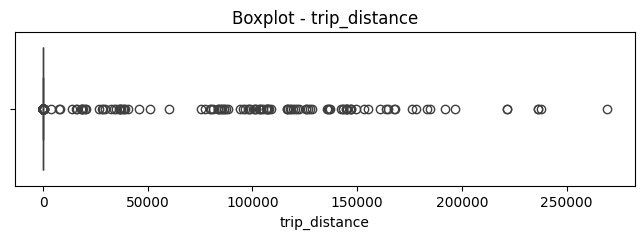

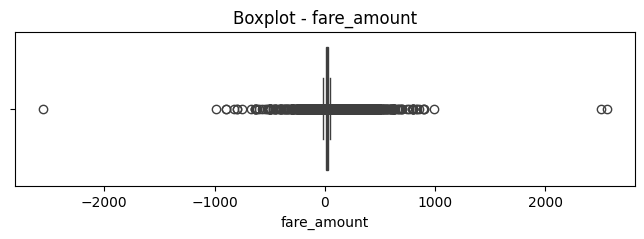

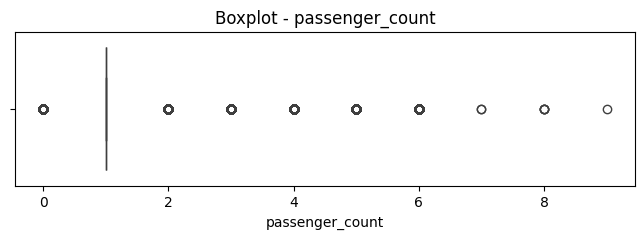

In [13]:
numeric_cols = [
    'trip_distance',
    'fare_amount',
    'passenger_count'
]

for col in numeric_cols:

    plt.figure(figsize=(8,2))

    sns.boxplot(
        x=df[col]
    )

    plt.title(f"Boxplot - {col}")

    plt.show()

## Observation

Outliers were identified in the following columns:

- trip_distance
- fare_amount

These columns contain a small number of extreme values that fall outside the typical range of taxi trips.

## Conclusion

Since the forecasting target is created using:

- Pickup Datetime
- Pickup Location ID

the identified outliers do not directly affect demand creation.

Therefore, no outlier treatment is performed at this stage.

However, if these features are used in future tasks such as fare prediction, trip duration prediction, customer behavior analysis, or machine learning feature engineering, the outliers should be investigated and handled appropriately.

Potential treatment methods may include:

- Business rule filtering
- IQR-based outlier removal
- Percentile capping (Winsorization)
- Domain-specific thresholds

For the current forecasting use case, the outliers are documented and retained to preserve valuable trip records.

# Cleaning Summary

## Purpose

Summarize all findings from the data cleaning process.

## Description

Review identified data quality issues and document the decisions taken before proceeding to feature engineering.

## Expected Outcome

- Consolidate cleaning findings.
- Record cleaning decisions.
- Prepare the dataset for demand creation.

In [16]:
df.to_parquet(
    "/home/ed/Desktop/NYC_Taxi_Demand_Forecasting/Yellow_Dataset/data/yellow_taxi_clean.parquet",
    index=False
)

print("Clean dataset saved successfully.")

Clean dataset saved successfully.
